In [1]:
from scipy import stats
from matplotlib import pyplot as plt
from factor_analysis import summarize_factors
from scipy.stats import kurtosis
from factor_model import *
from factor_model import build_portsort_factors
%matplotlib inline

In [2]:
def get_beta(F, R):
    date_all = sorted(R.index.unique())
    next_date = {date_all[i]: date_all[i + 1] for i in range(len(date_all) - 1)}

    valid_F_dates = [d for d in F.index if d in next_date]
    F_aligned = F.loc[valid_F_dates]
    R_aligned = R.loc[[next_date[d] for d in valid_F_dates]]
    R_aligned.index = F_aligned.index

    beta = np.full((F_aligned.shape[1], R_aligned.shape[1]), np.nan)
    for i in range(R_aligned.shape[1]):
        r = R_aligned.iloc[:, i]
        mask = r.notna()
        beta[:, i] = np.linalg.lstsq(F_aligned.values[mask], r.values[mask], rcond=None)[0]

    R_hat = F_aligned.values @ beta
    resid = R_aligned.values - R_hat
    res_std = np.sqrt(np.nanmean(resid**2, axis=0))
    return beta, res_std, resid, R_hat

def factor_sampler(F):
    F_mean = F.mean()
    F_cov = F.cov()
    sample = np.random.multivariate_normal(F_mean, F_cov)
    return sample

In [15]:

df = pd.read_parquet(f'data/train24y.parquet')

FACTORS = ['growth', 'momentum', 'quality', 'size', 'value', 'volatility']

zero_ratio = df.groupby('date')['returns'].apply(lambda x: (x == 0).mean())


In [16]:
print(zero_ratio[zero_ratio > 0.5])

date
2011-04-22    0.751241
2011-12-26    0.760759
2012-01-02    0.762025
2012-04-06    0.746675
2012-12-25    0.760581
2013-01-01    0.930512
2013-03-29    0.753477
2013-12-25    0.761185
2014-01-01    0.925646
2014-04-18    0.756910
2014-12-25    0.767846
2015-01-01    0.928660
2015-04-03    0.754342
2015-05-25    0.555348
2015-12-25    0.761642
2016-01-01    0.930104
2016-03-25    0.747388
2016-12-26    0.760710
2017-01-02    0.775398
2017-04-14    0.753978
2017-12-25    0.768434
2018-01-01    0.950030
2018-03-30    0.750764
2018-12-25    0.755378
2019-01-01    0.944034
2019-04-19    0.759236
2019-12-25    0.762546
2020-01-01    0.951652
2020-04-10    0.761496
2020-12-25    0.703924
2021-01-01    0.941820
2021-04-02    0.705737
Name: returns, dtype: float64


In [17]:
# remove zero return dates and dump to parquet

df = df[~df['date'].isin(zero_ratio[zero_ratio > 0.5].index)]
df.to_parquet("data/train24y_clean.parquet", index=False)

In [13]:
R = df.pivot_table(index='date', columns='csecid', values='returns')
chars = {f: df.pivot_table(index='date', columns='csecid', values=f) for f in FACTORS}

TypeError: '>' not supported between instances of 'str' and 'int'

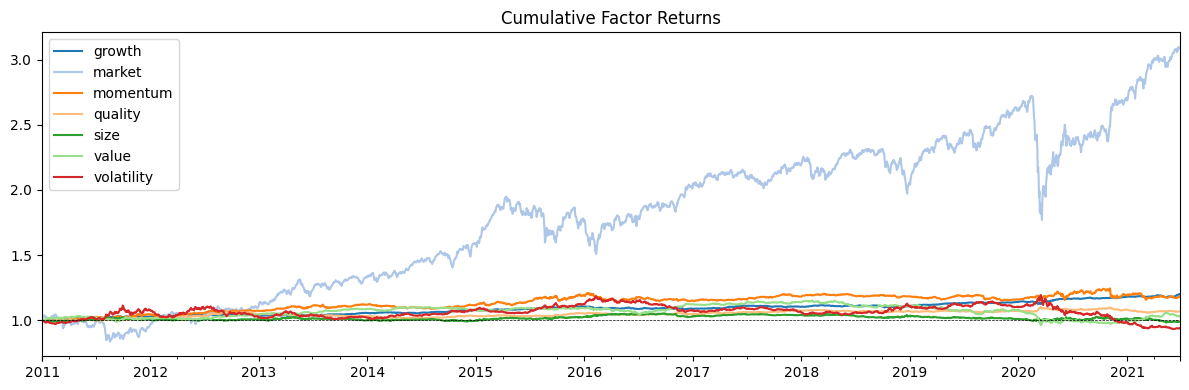

In [4]:
dates = sorted(R.index.unique())
date      = dates[2]
prev_date = dates[1]
R_t = R.loc[date].sort_index()

B_cols = [chars[f].loc[prev_date].sort_index() for f in FACTORS]
B_df = pd.concat(B_cols, axis=1)
factor_returns = []
valid_dates = []

for i in range(1, len(dates)):
    date      = dates[i]
    prev_date = dates[i - 1]

    R_t = R.loc[date].sort_index()
    B_cols = [chars[f].loc[prev_date].sort_index() for f in FACTORS]
    B_df = pd.concat(B_cols, axis=1)

    mask = R_t.notna() & B_df.notna().all(axis=1)

    R_clean = R_t[mask].values
    B_clean = np.column_stack([np.ones(mask.sum()), B_df[mask].values])


    F_t, _, _, _ = np.linalg.lstsq(B_clean, R_clean, rcond=None)
    eps = R_clean - B_clean @ F_t

    factor_returns.append(F_t)
    valid_dates.append(prev_date)

F = pd.DataFrame(factor_returns, index=valid_dates, columns=['market'] + FACTORS)
regression_summary = summarize_factors(F)

In [5]:
print(regression_summary)

            mean_annual(%)  vol_annual(%)  t_stat  p_value  significant
market               11.29          13.48    2.76   0.0058         True
growth                1.69           1.65    3.38   0.0007         True
momentum              1.62           3.75    1.43   0.1532        False
quality               0.63           1.70    1.21   0.2269        False
size                 -0.06           3.53   -0.05   0.9589        False
value                 0.32           3.23    0.33   0.7412        False
volatility           -0.43           5.26   -0.27   0.7867        False


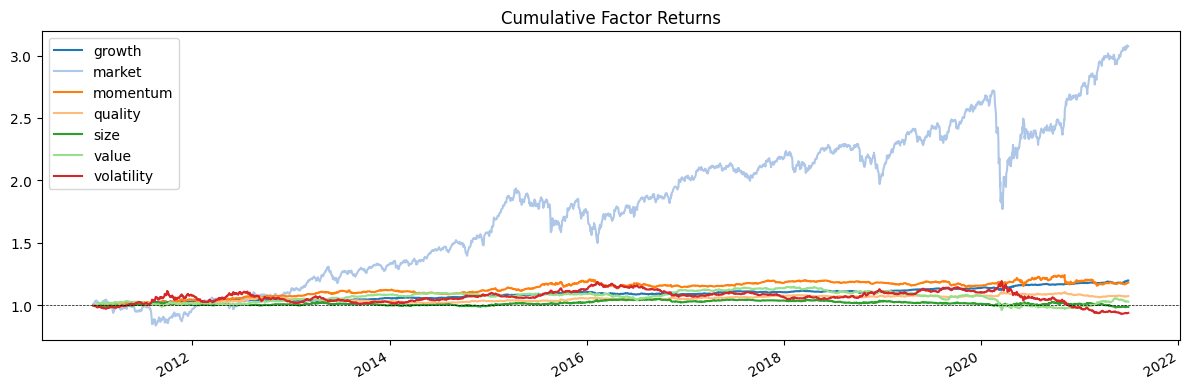

In [18]:
df   = load_parquet("data/train24y_clean.parquet")
R_actual, F_actual = build_regression_factors(df)
regression_summary = summarize_factors(F_actual.drop(columns='alpha'))

In [20]:
#pd.testing.assert_frame_equal(R, R_actual)
print(regression_summary)

            mean_annual(%)  vol_annual(%)  t_stat  p_value  significant
market               11.39          13.56    2.75   0.0060         True
growth                1.69           1.66    3.34   0.0009         True
momentum              1.62           3.77    1.41   0.1588        False
quality               0.67           1.71    1.28   0.2006        False
size                 -0.08           3.55   -0.07   0.9446        False
value                 0.31           3.24    0.31   0.7552        False
volatility           -0.46           5.28   -0.28   0.7764        False


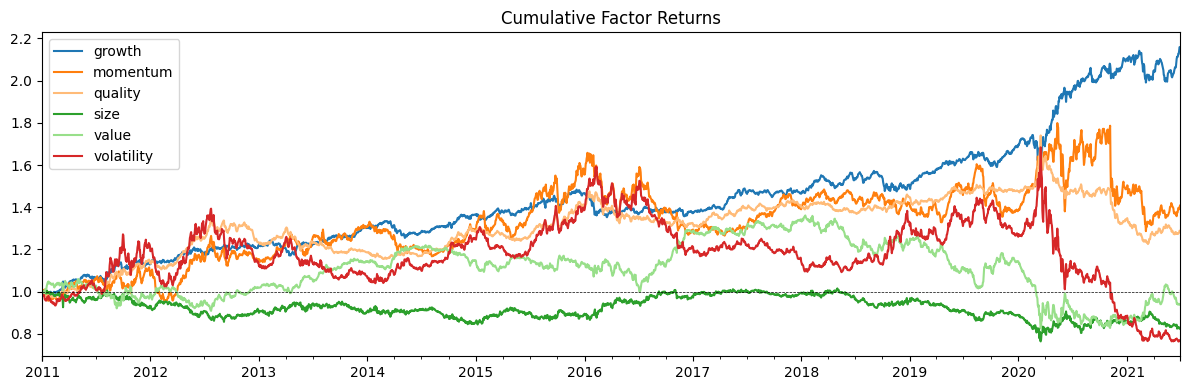

In [8]:
J = 5
dates = sorted(R.index.unique())
all_port_dfs = {}
all_spreads  = {}

for f in FACTORS:
    ports, spreads, valid_dates = [], [], []
    for i in range(1, len(dates)):
        date      = dates[i]
        prev_date = dates[i - 1]
        R_t       = R.loc[date]
        char_prev = chars[f].loc[prev_date]
        mask      = R_t.notna() & char_prev.notna()
        r = R_t[mask]; c = char_prev[mask]
        labels   = pd.qcut(c, q=J, labels=False, duplicates="drop")
        port_ret = r.groupby(labels).mean().reindex(range(J))
        ports.append(port_ret.values)
        spreads.append(port_ret.iloc[-1] - port_ret.iloc[0])
        valid_dates.append(prev_date)
    all_port_dfs[f] = pd.DataFrame(ports, index=valid_dates,
                                   columns=[f"Q{j+1}" for j in range(J)])
    all_spreads[f]  = pd.Series(spreads, index=valid_dates, name=f)


portsort_summary = summarize_factors(pd.DataFrame(all_spreads))


In [9]:
print(portsort_summary.to_string())

            mean_annual(%)  vol_annual(%)  t_stat  p_value  significant
growth                7.34           7.26    3.33   0.0009         True
momentum              4.15          14.09    0.97   0.3323        False
quality               2.57           6.87    1.23   0.2180        False
size                 -1.17          11.09   -0.35   0.7277        False
value                 0.01          10.96    0.00   0.9975        False
volatility           -1.22          15.46   -0.26   0.7951        False


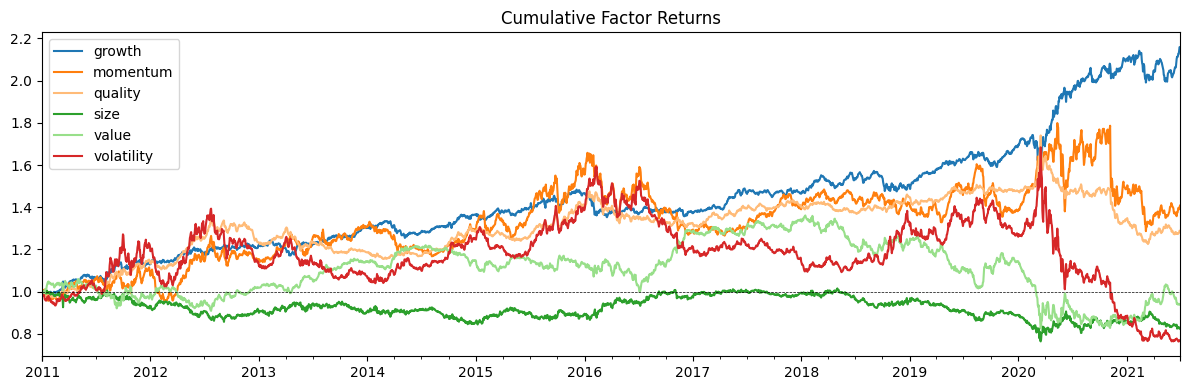

In [10]:
df   = load_parquet("data/train24y.parquet")
R_actual, F_actual = build_portsort_factors(df)
portsort_summary = summarize_factors(F_actual)

In [11]:
print(portsort_summary.to_string())

            mean_annual(%)  vol_annual(%)  t_stat  p_value  significant
growth                7.34           7.26    3.33   0.0009         True
momentum              4.15          14.09    0.97   0.3323        False
quality               2.57           6.87    1.23   0.2180        False
size                 -1.17          11.09   -0.35   0.7277        False
value                 0.01          10.96    0.00   0.9975        False
volatility           -1.22          15.46   -0.26   0.7951        False


In [12]:
F_regression = F
F_portsort = pd.DataFrame(all_spreads)

In [235]:
# save factor returns
F_regression.to_csv(f"data/factor_returns_regression.csv")
F_portsort.to_csv(f"data/factor_returns_portsort.csv")

In [13]:
FF = F_regression
beta_r, res_std, resid, R_hat = get_beta(FF, R)

In [23]:
def reconstruct_return(fs, beta, res_std):
    # step1: draw N factor return samples
    #fs_all = F_regression_diffusion
    # step2: idiosyncratic
    N = fs.shape[0]
    return (fs @ beta)  + np.random.normal(0, 1, size=(N, len(res_std))) * res_std[None, :]

In [15]:
model = fit_beta(FF, R)

In [18]:
np.testing.assert_array_almost_equal(model.beta, beta_r)
np.testing.assert_array_almost_equal(model.res_std, res_std)

In [21]:
model.save("model/test")

Saved → model/test/_factors.csv + model/test/_model.npz


In [26]:
samples_actual = reconstruct_returns(model, FF.values)
samples = reconstruct_return(FF.values, beta_r, res_std)
samples.shape, samples_actual.shape

((2738, 2758), (2738, 2758))

In [243]:
# PSM
fs_list = [factor_sampler(FF) for _ in range(N)]
fs_all = np.column_stack(fs_list).T  # (K, N)
PSM_sample = reconstruct_return(fs_all)
np.save("samples/PSM2048.npy", PSM_sample)

In [246]:
# PSM diffusion
fs_ddpm = np.load("samples/factor_ddpm_2048.npy")
fs_ddpm = np.hstack([np.ones((fs_ddpm.shape[0], 1)), fs_ddpm])
PSMDiff_sample = reconstruct_return(fs_ddpm)
np.save("samples/PSMDiff2048.npy", PSMDiff_sample)

In [247]:
fs_ddpm.shape, fs_all.shape

((2048, 8), (2048, 8))

In [101]:
# synthesized
N = FF.shape[0]
fs_resample = FF.values  # (K, N)
PSMResample_sample = reconstruct_return(fs_resample)
np.save("data/PSMExactlys3913.npy", PSMResample_sample)

In [205]:
R_real = R.values
res_mean = np.nanmean(resid, axis=0)
R_gen = (FF.values @ beta_r)  + np.random.normal(0, 1, size=(N, len(res_std))) * res_std[None, :]
np.save("data/PSMExactlys3913.npy", R_gen)

In [258]:
Fb = FF.values @ beta_r
kurt_fb = kurtosis(Fb, axis=0, nan_policy='omit')
kurt_res = kurtosis(resid, axis=0, nan_policy='omit')
kurt_sum = kurtosis(Fb + resid, axis=0, nan_policy='omit')
kurt_sampled = kurtosis(Fb + np.random.normal(0, 1, size=(FF.shape[0], len(res_std))) * res_std[None, :], axis=0, nan_policy='omit')
print(f"Factor part kurtosis std: {np.nanmean(kurt_fb):.2f}")
print(f"Residual kurtosis std: {np.nanmean(kurt_res):.2f}")
print(f"Total return kurtosis std: {np.nanmean(kurt_sum):.2f}")
print(f"Sampled return kurtosis std: {np.nanmean(kurt_sampled):.2f}")

Factor part kurtosis std: 10.33
Residual kurtosis std: 17.41
Total return kurtosis std: 13.22
Sampled return kurtosis std: 1.22


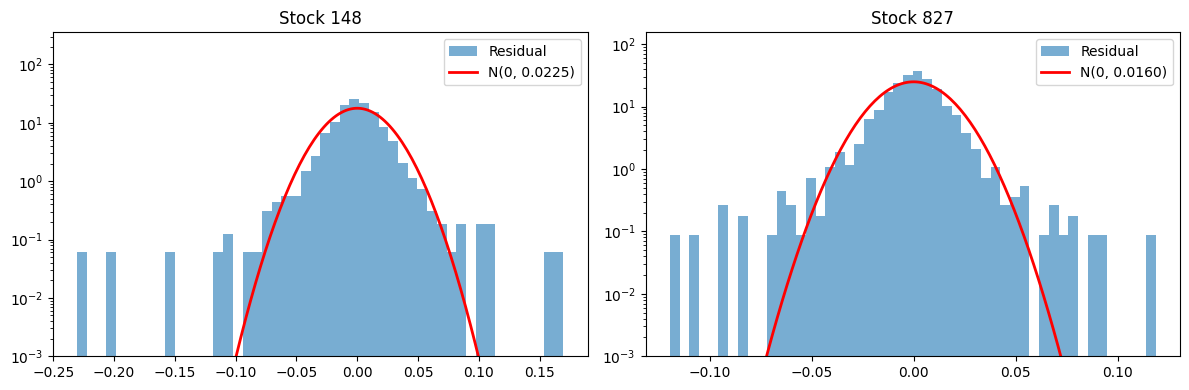

In [181]:
from scipy.stats import norm

s1, s2 = np.random.choice(resid.shape[1], 2, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, s in zip(axes, [s1, s2]):
    r = resid[:, s]
    r = r[~np.isnan(r)]
    ax.hist(r, bins=50, density=True, alpha=0.6, label='Residual')

    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, norm.pdf(x, 0, res_std[s]), 'r-', linewidth=2, label=f'N(0, {res_std[s]:.4f})')
    ax.set_yscale('log')
    ax.set_ylim(1e-3, None)
    ax.set_title(f'Stock {s}')
    ax.legend()

plt.tight_layout()

In [183]:
R_real.shape, R_gen.shape
np.save("data/PSMExactlys3913.npy", R_gen)

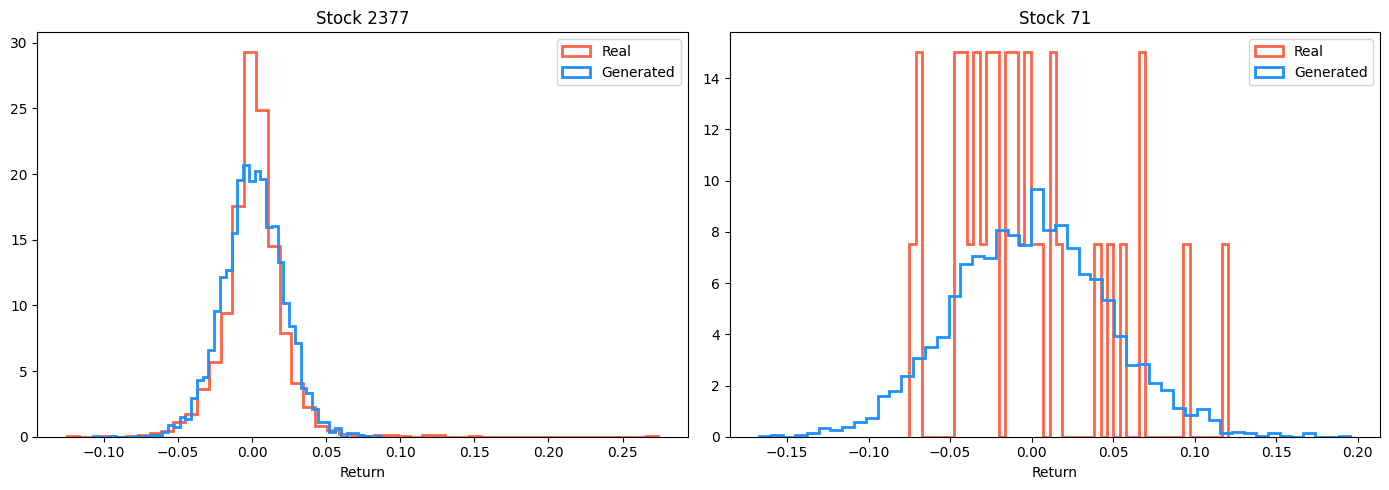

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

s1, s2 = np.random.choice(R_real.shape[1], 2, replace=False)

for ax, s in zip(axes, [s1, s2]):
    real_s = R_real[:, s][~np.isnan(R_real[:, s])]
    gen_s = R_gen[:, s][~np.isnan(R_gen[:, s])]
    #without_res = R_without_res[:, s][~np.isnan(R_without_res[:, s])]

    ax.hist(real_s, bins=50, density=True, label='Real', color='tomato', histtype='step', linewidth=2)
    ax.hist(gen_s, bins=50, density=True, label='Generated', color='dodgerblue', histtype='step', linewidth=2)
    #ax.hist(without_res, bins=50, density=True, label='Without Residual', color='blue', histtype='step', linewidth=2)

    ax.set_title(f'Stock {s}')
    ax.set_xlabel('Return')
    ax.legend()

plt.tight_layout()
plt.show()

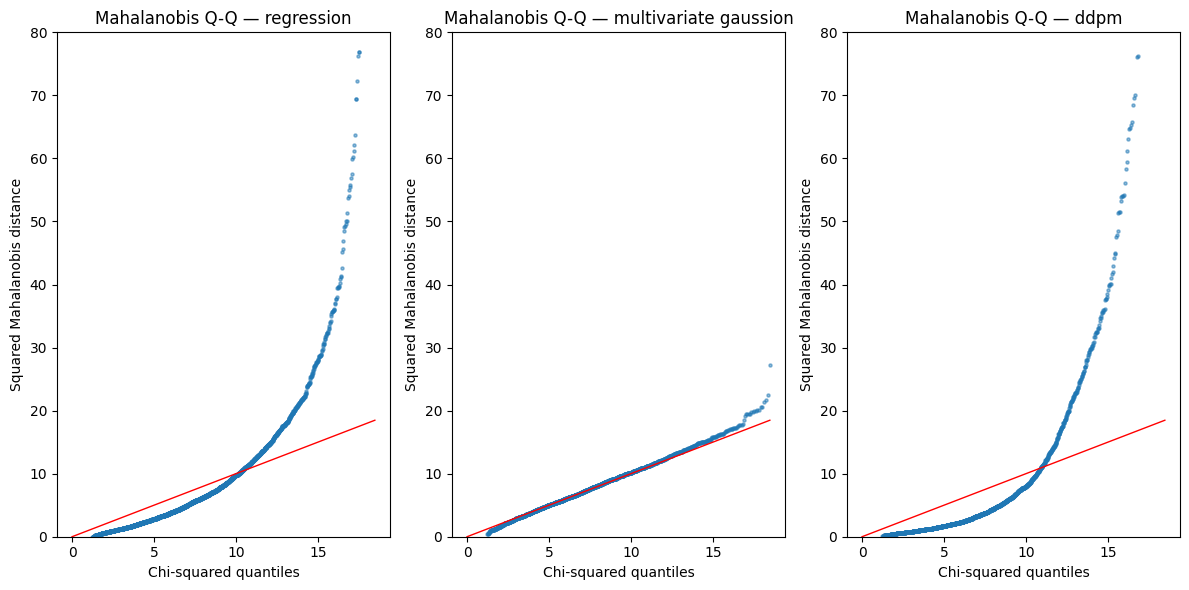

In [253]:
fig, (ax1, ax2, ax4) = plt.subplots(1, 3, figsize=(12, 6))

axs = [(ax1, F_regression.values, "regression"),
                     (ax2, fs_all, "multivariate gaussion"),
       (ax4, fs_ddpm, "ddpm")]
for ax, XX, title in axs:
    X = XX[:, 1:]
    p = X.shape[1]
    mean = X.mean(axis=0)
    cov = np.cov(X, rowvar=False)
    diff = X - mean
    d2 = (diff @ np.linalg.inv(cov) * diff).sum(axis=1)
    quantiles = stats.chi2.ppf(np.linspace(0.01, 0.99, len(d2)), df=p)
    ax.set_ylim(0, 80)
    ax.scatter(quantiles, np.sort(d2), s=5, alpha=0.5)
    ax.plot([0, quantiles.max()], [0, quantiles.max()], color="red", linewidth=1)
    ax.set_xlabel("Chi-squared quantiles")
    ax.set_ylabel("Squared Mahalanobis distance")
    ax.set_title(f"Mahalanobis Q-Q — {title}")

plt.tight_layout()
plt.show()



In [40]:
# Residual Dynamics
beta_r, res_std, resid, R_hat = get_beta(F_regression, R)

In [41]:
res_sample = np.random.normal(0, 1, size=res_std.shape)

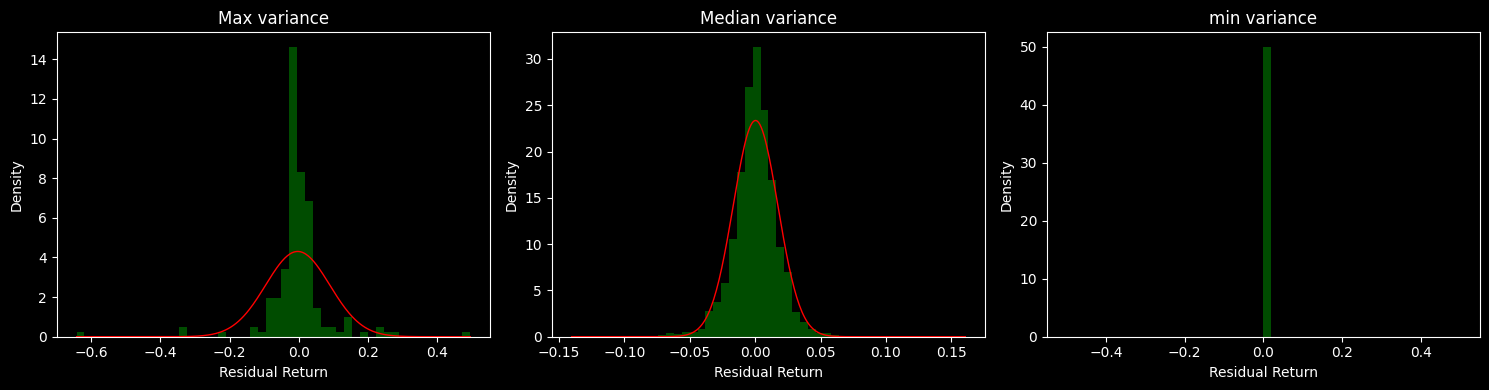

In [42]:
resid_var = np.nanvar(resid, axis=0)
idx_max    = np.nanargmax(resid_var)
idx_median = np.argsort(resid_var)[len(resid_var) // 2]
idx_min   = np.nanargmin(np.abs(resid_var))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx, label in zip(axes,
                         [idx_max, idx_median, idx_min],
                         ['Max variance', 'Median variance', 'min variance']):
  r = resid[:, idx]
  r = r[~np.isnan(r)]
  ax.hist(r, bins=50, density=True, alpha=0.6, color='g')
  x = np.linspace(r.min(), r.max(), 300)
  ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color='red', linewidth=1)
  ax.set_title(label)
  ax.set_xlabel('Residual Return')
  ax.set_ylabel('Density')

plt.tight_layout()
plt.show()